# Dataset de autismo

Nuestro dataset recoge datos de pacientes con y sin autismo

In [9]:
import numpy as np
from functions_scripts.load import read_data
from classes import Preparador, Model, Imputer, Transformador
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from matplotlib import pyplot as plt
import pandas as pd                        

seed = 123
np.random.seed(123)
test_size = 0.2

  a1_score  a2_score  a3_score  a4_score  a5_score a6_score  a7_score  \
0    agree  disagree  disagree  disagree     agree    agree     agree   
1    agree  disagree     agree  disagree     agree    agree  disagree   
2    agree  disagree     agree  disagree  disagree    agree     agree   
3    agree  disagree     agree  disagree     agree    agree     agree   
4    agree     agree     agree     agree     agree    agree  disagree   

  a8_score  a9_score a10_score   age gender       ethnicity jaundice  \
0    agree     agree  disagree  26.0      f  white-european       no   
1    agree     agree     agree  24.0      m          latino       no   
2    agree  disagree     agree  27.0      m          latino      yes   
3    agree     agree     agree  35.0      f  white-european       no   
4    agree     agree  disagree  40.0      f             NaN       no   

  family_pdd country_of_res used_app_before relation class  
0         no   unitedstates              no     self    no  
1     

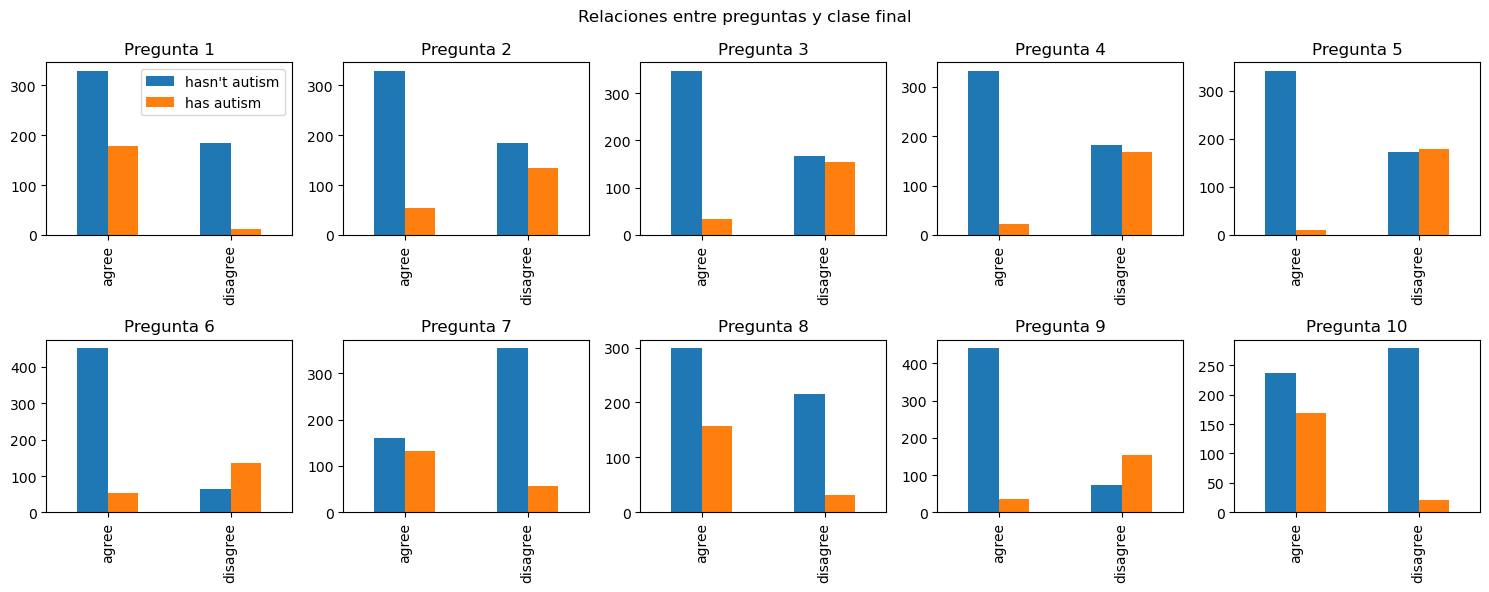

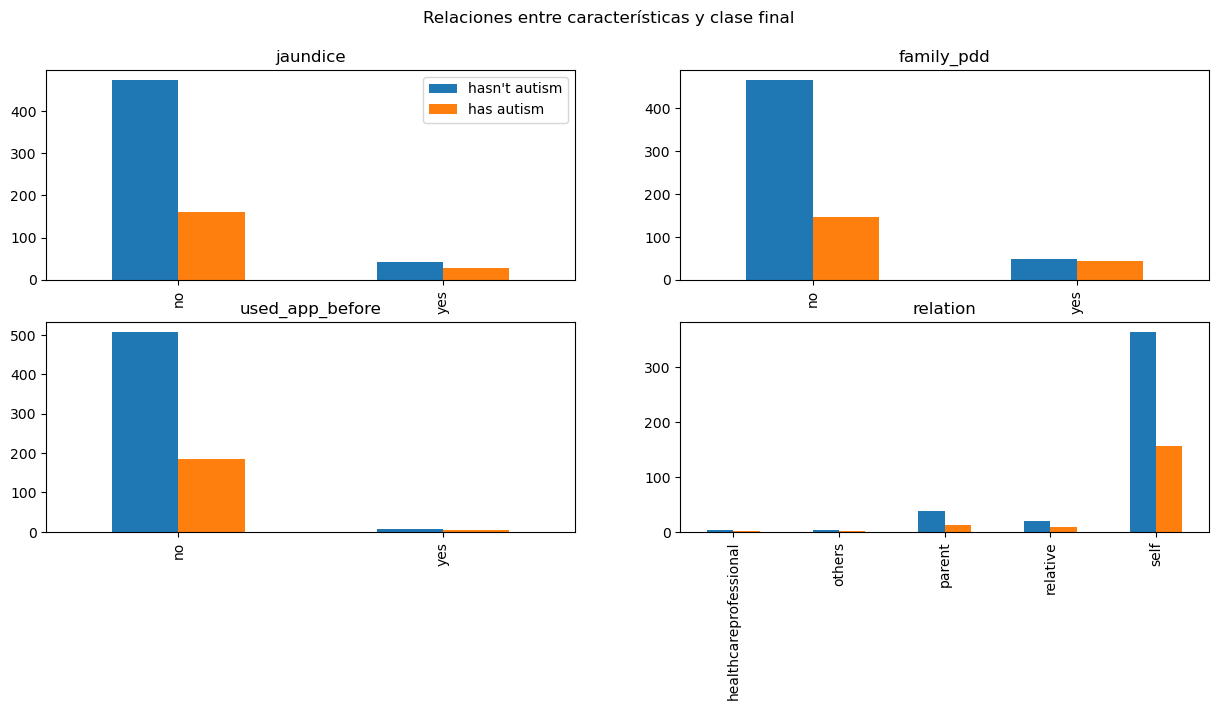

In [12]:
df = Preparador().preparar(read_data())
print(df.head())

def get_graphs(X, y):
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.ravel()

    for i in range(10):
        col = X.columns[i]
        ct = pd.crosstab(X[col], y) # filas: agree/disagree, cols: 0/1                                   
        ct.columns = ["hasn't autism", "has autism"]
        ct.plot(kind="bar", ax=axes[i], legend=(i == 0))
        axes[i].set_title(f"Pregunta {i+1}")
        axes[i].set_xlabel("")
                
    fig.suptitle("Relaciones entre preguntas y clase final")                                                      
    fig.tight_layout()
    plt.show()

    fig, axes = plt.subplots(2,2, figsize=(15, 6))
    axes = axes.ravel()
    fig.suptitle("Relaciones entre características y clase final")
    columns = ["jaundice", "family_pdd", "used_app_before", "relation"]
    for i in range(4):
        col = columns[i]
        ct = pd.crosstab(X[col], y)                                   
        ct.columns = ["hasn't autism", "has autism"]
        ct.plot(kind="bar", ax=axes[i], legend=(i == 0))
        axes[i].set_title(f"{col}")
        axes[i].set_xlabel("")

    plt.show()

X, y = df[df.columns[:-1]], df[df.columns[-1]]

get_graphs(X, y)

## Hito 1
```
en este hito se debe tener el problema elegido, se debe haber
determinado la métrica de rendimiento y la metodología de validación de
modelos a utilizar. Además, se deberán haber analizado las variables de entrada
y su relación con la variable a predecir. También se deberá haber creado una
primera solución automatizada (ColumnTransformer, Pipeline) al problema (con
KNN) que se irá mejorando conforme pasen las semanas. 
```

In [ ]:
# Leemos los datos y dejamos el dataframe más organizado
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed, stratify=y)

modelo = Model(
    imputador=Imputer(),
    transformador=Transformador(),
    clasificador=KNeighborsClassifier(),
    estandarizador=StandardScaler()
)

param_grid = {
    "imputador__metodo_imputacion_vars_num": ["media", "mediana"],
    "imputador__metodo_imputacion_vars_cat": ["moda", "missing"],
    "transformador__metodo_cat_num": ["orden", "conteo", "ohe", "binary"],
    "estandarizador": [StandardScaler(), RobustScaler(), MinMaxScaler(), 'passthrough'], # passthrough evalúa dejar estandarizador en None
    "outlier__deteccion": ["iqr", "mediastd"],
    "outlier__reemplazo": ["mediana", "media", "min", "max", "moda"],
    # "modelo__n_neighbors": [1, 2, 3, 5, 8],                       # Dejar comentado hasta el final (antes de la entrega)
    # "modelo__weights": ["uniform", "distance"],                   # Dejar comentado hasta el final (antes de la entrega)
    # "modelo__p": [1, 2],                                          # Dejar comentado hasta el final (antes de la entrega)
}

modelo.set_params(param_grid)
modelo.set_scorer("roc_auc")

# Elegir metrica dependiente e independiente del umbral y siempre usar la misma
modelo.fit(X_train, y_train)

for k, v in modelo.pipe.best_params_.items():
    print(f"Entre {param_grid[k]}\nMejor {k}: {v}\n")

print(modelo.f1_score(X_test, y_test))
print(modelo.confusion_matrix(X_test, y_test))

ValueError: [ERROR]: El diccionario de parametros introducido utiliza nombres inválidos.
Usar: 'imputador', 'transformador', 'estandarizador' o 'modelo'.

## Hito 2
```
en este hito se deberá haber analizado el comportamiento de las
diferentes técnicas de preparación de datos que involucren tratamiento de
variables (estandarización, transformación del tipo de variable, creación de
nuevas variables, selección de variables) así como la detección de outliers y la
imputación de valores perdidos (en caso de que haya). 
```